In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import pandas as pd

In [2]:
# Specify the filename for the .pkl file
filename = "collision_stats_final.pkl"
# Load the dictionary back from the .pkl file
with open(filename, "rb") as f:
    stats = pickle.load(f)

# Specify the filename for the .pkl file
filename = "collision_fcnn.pkl"
# Load the dictionary back from the .pkl file
with open(filename, "rb") as f:
    stats_fcnn = pickle.load(f)

In [3]:
print(stats_fcnn)

{0: {'FCNN': {0.1: {'time': 251.50059604644775, 'carbon': 0.002175818545865125, 'epsilon': np.float64(0.7111111137602064), 'acc': 0.9109054956534717, 'pre_0': 0.9080050534053061, 'pre_1': 0.9123010610079576, 'pre_avg': 0.9101530572066319, 'rec_0': 0.8328241862424944, 'rec_1': 0.9537261698440208, 'rec_avg': 0.8932751780432576, 'f1_0': 0.8687912087912089, 'f1_1': 0.9325538044399255, 'f1_avg': 0.9006725066155672}, 0.3: {'time': 367.2131419181824, 'carbon': 0.003197602199115424, 'epsilon': np.float64(0.6800000115235647), 'acc': 0.8953102264671865, 'pre_0': 0.9429063452112862, 'pre_1': 0.876649007998338, 'pre_avg': 0.9097776766048121, 'rec_0': 0.7498156536395238, 'rec_1': 0.9751010976314269, 'rec_avg': 0.8624583756354753, 'f1_0': 0.8353479638540078, 'f1_1': 0.923257849250629, 'f1_avg': 0.8793029065523184}, 0.5: {'time': 366.09613823890686, 'carbon': 0.0031863250684273643, 'epsilon': np.float64(0.7490153312683105), 'acc': 0.8979218744170429, 'pre_0': 0.8095848987446165, 'pre_1': 0.9585903083

In [4]:
iterations = list(stats.keys())
all_methods = list(stats[0].keys())
percentages = list(stats[0]['FES'].keys())
metrics = list(stats[0]['FES'][1.0].keys())

In [5]:
median_stats = {}
for method_key in all_methods:
    median_stats[method_key] = {}
    for percentage_key in percentages:
        median_stats[method_key][percentage_key] = {}
        for metric_key in metrics:
            if percentage_key != 1.0 and method_key == "FCNN":
                median_stats[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn[iter][method_key][percentage_key][metric_key] 
                for iter in iterations 
                if stats_fcnn[iter][method_key][percentage_key][metric_key] is not None ])
            else:
                median_stats[method_key][percentage_key][metric_key] = np.median([
                stats[iter][method_key][percentage_key][metric_key] 
                for iter in iterations 
                if stats[iter][method_key][percentage_key][metric_key] is not None ])  

## How does the reduction affects the efficiency?

In [6]:
time_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        time_df.loc[m][p] = round(median_stats[m][p]['time'],2)
time_df_t = time_df.transpose()
time_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\327068377.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df.loc[m][p] = round(median_stats[m][p]['time'],2)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,251.5,52.76,78.07,64.09,67.9,55.55,251.28
0.3,367.21,157.64,191.67,190.43,195.48,161.25,312.54
0.5,366.1,262.78,303.96,310.28,318.43,267.66,374.7
0.7,383.18,367.0,408.02,423.62,433.1,371.16,436.25
0.9,386.03,471.83,522.8,532.15,546.48,478.67,499.62
1.0,529.73,529.73,529.73,529.73,529.73,529.73,529.73


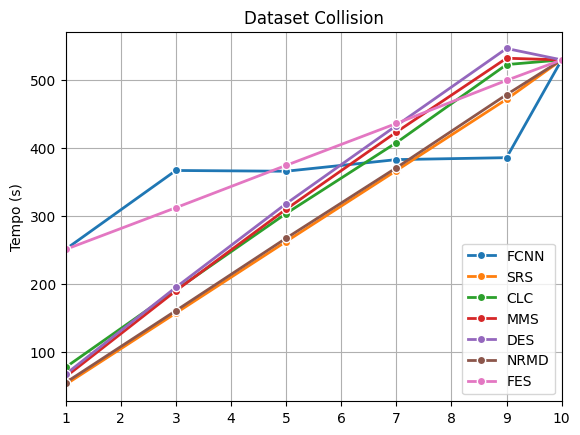

In [7]:
for idx, row in time_df.iterrows():
    plt.plot(
        time_df.columns * 10,
        row,
        label=idx,
        marker='o',
        markersize=6,
        markeredgecolor='white',
        linewidth=2
    )

plt.ylabel('Tempo (s)')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

In [8]:
carbon_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        carbon_df.loc[m][p] = round(median_stats[m][p]['carbon'] * 1000,3)
carbon_df_t = carbon_df.transpose()
carbon_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\171476848.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  carbon_df.loc[m][p] = round(median_stats[m][p]['carbon'] * 1000,3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,2.176,0.459,0.682,0.557,0.592,0.483,2.188
0.3,3.198,1.372,1.675,1.656,1.713,1.401,2.72
0.5,3.186,2.286,2.635,2.7,2.791,2.327,3.275
0.7,3.338,3.199,3.547,3.683,3.786,3.232,3.83
0.9,3.359,4.137,4.538,4.629,4.75,4.167,4.356
1.0,4.6,4.6,4.6,4.6,4.6,4.6,4.6


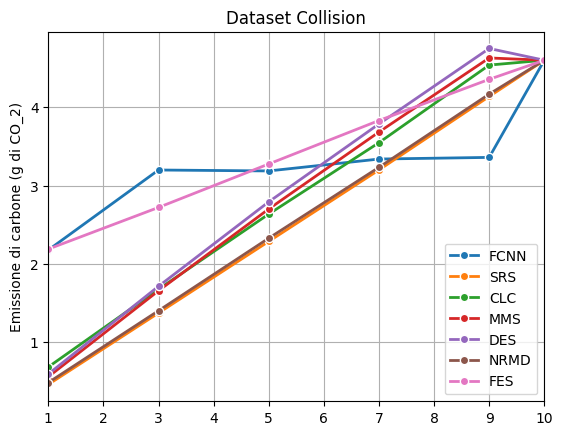

In [9]:
for idx, row in carbon_df.iterrows():
    plt.plot(carbon_df.columns * 10, row, label=idx, marker='o',
        markersize=6,
        markeredgecolor='white',
        linewidth=2)
plt.ylabel('Emissione di carbone (g di CO_2)')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

## How $\varepsilon$-representative are the reduced datasets?

In [10]:
epsilon_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        epsilon_df.loc[m][p] = round(median_stats[m][p]['epsilon'],3)
epsilon_df_t = epsilon_df.transpose()
epsilon_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\2445719397.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df.loc[m][p] = round(median_stats[m][p]['epsilon'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.711,0.625,0.529,0.4,0.628,0.959,0.823
0.3,0.68,0.55,0.58,0.332,0.533,0.944,0.67
0.5,0.749,0.55,0.459,0.293,0.533,0.85,0.573
0.7,0.749,0.55,0.419,0.244,0.511,0.754,0.474
0.9,0.758,0.427,0.334,0.22,0.433,0.612,0.392
1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


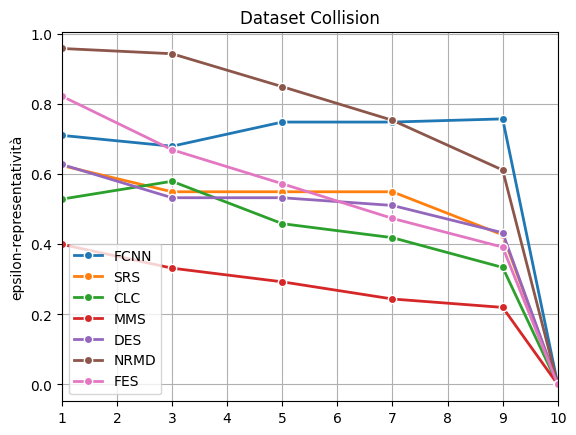

In [11]:
for idx, row in epsilon_df.iterrows():
    plt.plot(epsilon_df.columns * 10, row, label=idx, marker='o',
        markersize=6,
        markeredgecolor='white',
        linewidth=2)
plt.ylabel('epsilon-representatività')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

## How does the reduction affect the performance?

In [12]:
accuracy_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        accuracy_df.loc[m][p] = round(median_stats[m][p]['acc'],3)
accuracy_df_t = accuracy_df.transpose()
accuracy_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\2707575944.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df.loc[m][p] = round(median_stats[m][p]['acc'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.911,0.894,0.874,0.865,0.897,0.823,0.646
0.3,0.895,0.895,0.893,0.881,0.896,0.854,0.865
0.5,0.898,0.912,0.892,0.896,0.915,0.862,0.914
0.7,0.905,0.915,0.905,0.902,0.914,0.901,0.918
0.9,0.898,0.911,0.909,0.913,0.916,0.904,0.912
1.0,0.905,0.905,0.905,0.905,0.905,0.905,0.905


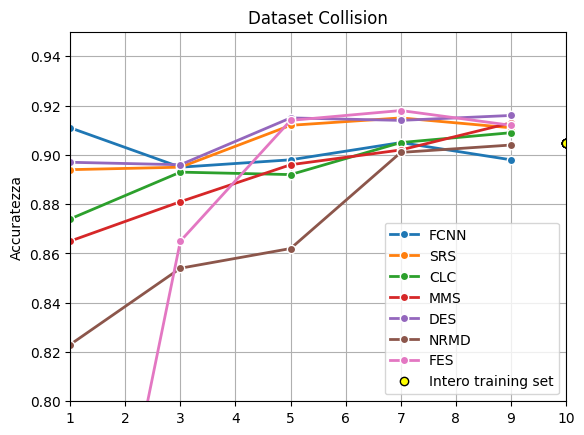

In [36]:
for idx, row in accuracy_df.iterrows():
    x_vals = accuracy_df.columns * 10
    y_vals = row.values

    # Traccia solo fino al penultimo punto
    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    # Disegna il punto finale separato
    plt.plot(x_vals[-1], y_vals[-1], marker='o', color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')  # Nessuna linea
    
# Aggiungi un punto fittizio solo per la legenda
plt.plot([], [], marker='o', color='yellow', markersize=6,
        markeredgecolor='black', linestyle='None',
        label='Intero training set')

plt.ylabel('Accuratezza')
plt.title('Dataset Collision')
plt.xlim(1, 10)
plt.ylim(0.80, 0.95)
plt.grid()
plt.legend()
plt.show()


In [14]:
precision_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        precision_df.loc[m][p] = round(median_stats[m][p]['pre_avg'],3)
precision_df_t = precision_df.transpose()
precision_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\105675181.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df.loc[m][p] = round(median_stats[m][p]['pre_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.91,0.885,0.861,0.851,0.89,0.819,0.646
0.3,0.91,0.881,0.879,0.898,0.882,0.856,0.881
0.5,0.884,0.903,0.878,0.882,0.911,0.848,0.915
0.7,0.911,0.905,0.892,0.888,0.914,0.889,0.916
0.9,0.885,0.9,0.897,0.906,0.914,0.89,0.907
1.0,0.892,0.892,0.892,0.892,0.892,0.892,0.892


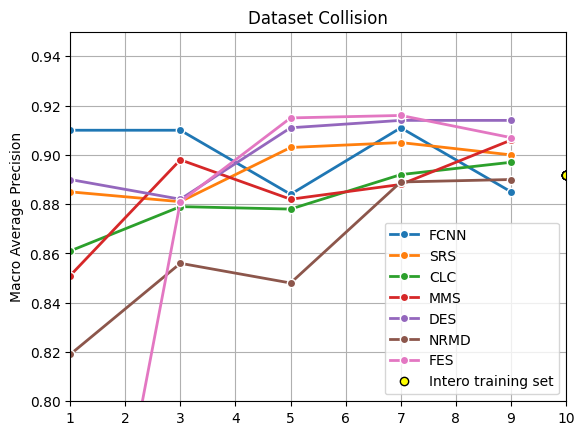

In [39]:
for idx, row in precision_df.iterrows():
    x_vals = precision_df.columns * 10
    y_vals = row.values

    # Traccia la curva fino al penultimo punto
    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    # Aggiungi il punto finale (separato)
    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

# Punto fittizio per legenda
plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.ylabel('Macro Average Precision')
plt.title('Dataset Collision')
plt.xlim(1, 10)
plt.ylim(0.80, 0.95)
plt.grid()
plt.legend()
plt.show()


In [16]:
recall_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        recall_df.loc[m][p] = round(median_stats[m][p]['rec_avg'],3)
recall_df_t = recall_df.transpose()
recall_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\4002456481.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df.loc[m][p] = round(median_stats[m][p]['rec_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.893,0.884,0.888,0.872,0.884,0.784,0.5
0.3,0.862,0.904,0.902,0.842,0.899,0.819,0.823
0.5,0.905,0.905,0.9,0.905,0.902,0.873,0.896
0.7,0.879,0.911,0.91,0.91,0.896,0.896,0.902
0.9,0.901,0.908,0.91,0.904,0.901,0.911,0.899
1.0,0.91,0.91,0.91,0.91,0.91,0.91,0.91


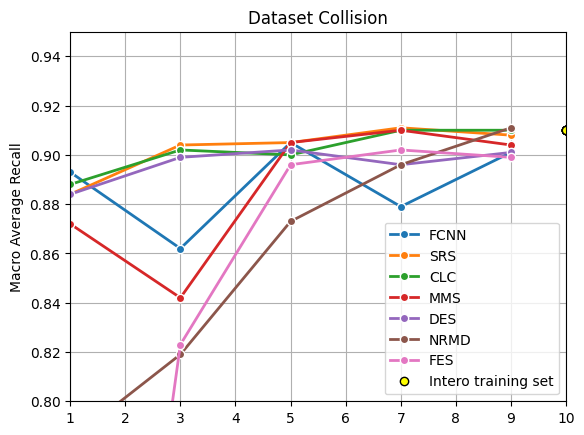

In [41]:
for idx, row in recall_df.iterrows():
    x_vals = recall_df.columns * 10
    y_vals = row.values
    # Traccia la curva fino al penultimo punto
    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    # Aggiungi il punto finale (separato)
    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

# Punto fittizio per legenda
plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.ylabel('Macro Average Recall')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

In [18]:
f1score_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        f1score_df.loc[m][p] = round(median_stats[m][p]['f1_avg'],3)
f1score_df_t = f1score_df.transpose()
f1score_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\374755532.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df.loc[m][p] = round(median_stats[m][p]['f1_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.901,0.884,0.868,0.858,0.887,0.796,0.785
0.3,0.879,0.889,0.887,0.861,0.889,0.832,0.842
0.5,0.892,0.904,0.886,0.89,0.906,0.855,0.904
0.7,0.892,0.908,0.899,0.896,0.904,0.893,0.908
0.9,0.891,0.904,0.903,0.905,0.907,0.898,0.903
1.0,0.899,0.899,0.899,0.899,0.899,0.899,0.899


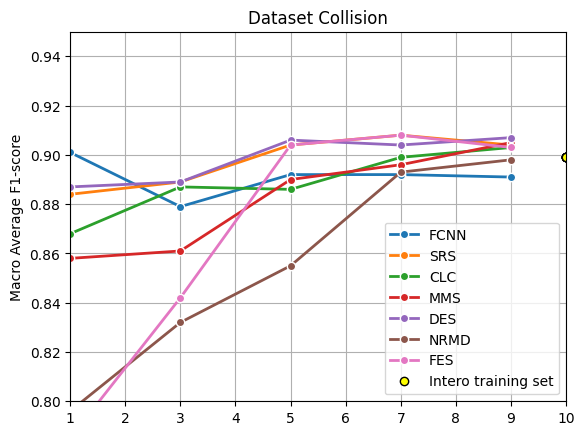

In [42]:
for idx, row in f1score_df.iterrows():
    x_vals = f1score_df.columns * 10
    y_vals = row.values

    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    # Aggiungi il punto finale (separato)
    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

# Punto fittizio per legenda
plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.ylabel('Macro Average F1-score')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

## Does the $\varepsilon$-representativeness affect the performance?

In [20]:
epsilon_acc_df = pd.DataFrame(index=['rho', 'p-value'], columns=percentages[:-1])
for p in percentages[:-1]:
    epsilon_values = []
    accuracy_values = []
    for iter in iterations:
        for m in all_methods:
            # Only add values if both are not None
            if stats[iter][m][p]['epsilon'] is not None and stats[iter][m][p]['acc'] is not None:
                epsilon_values.append(stats[iter][m][p]['epsilon'])
                accuracy_values.append(stats[iter][m][p]['acc'])
    rho, pvalue = spearmanr(epsilon_values, accuracy_values)
    epsilon_acc_df.loc['rho'][p], epsilon_acc_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)
epsilon_acc_df

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\1553345712.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_acc_df.loc['rho'][p], epsilon_acc_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)


,0.1,0.3,0.5,0.7,0.9
rho,-0.25,-0.57,-0.39,-0.39,-0.54
p-value,0.59,0.18,0.38,0.38,0.22


In [21]:
epsilon_f1_df = pd.DataFrame(index=['rho', 'p-value'], columns=percentages[:-1])
for p in percentages[:-1]:
    epsilon_values = []
    f1_values = []
    for iter in iterations:
        for m in all_methods:
            # Only add values if both are not None
            if stats[iter][m][p]['epsilon'] is not None and stats[iter][m][p]['f1_avg'] is not None:
                epsilon_values.append(stats[iter][m][p]['epsilon'])
                f1_values.append(stats[iter][m][p]['f1_avg'])
    rho, pvalue = spearmanr(epsilon_values, f1_values)
    epsilon_f1_df.loc['rho'][p], epsilon_f1_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)
epsilon_f1_df

C:\Users\aless\AppData\Local\Temp\ipykernel_33920\453174950.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_f1_df.loc['rho'][p], epsilon_f1_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)


,0.1,0.3,0.5,0.7,0.9
rho,-0.25,-0.54,-0.39,-0.39,-0.5
p-value,0.59,0.22,0.38,0.38,0.25
